# EDA — Tipos de cambio y riesgo de crédito (Konfio)

Notebook exploratorio sobre las tablas Iceberg generadas por el pipeline (`src/main.py`).

Requiere que el pipeline ya se haya corrido al menos una vez (`docker compose up`) para que existan datos en `warehouse/`.

Cómo correr este notebook: ver instrucciones en el README, sección "Notebook de EDA".

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt

from src.common import get_spark_session
from src import load

spark = get_spark_session("konfio-eda-notebook")
load.ensure_database(spark)

enriched_sdf = load.read_table(spark, "enriched")
monthly_sdf = load.read_table(spark, "monthly_metrics")
anomalies_sdf = load.read_table(spark, "anomalies")

enriched_pdf = enriched_sdf.toPandas().sort_values("date")
monthly_pdf = monthly_sdf.toPandas().sort_values(["currency", "year", "month"])
anomalies_pdf = anomalies_sdf.toPandas().sort_values("date")

print(f"tipos_cambio_enriquecidos: {len(enriched_pdf)} filas")
print(f"metricas_mensuales: {len(monthly_pdf)} filas")
print(f"anomalias: {len(anomalies_pdf)} filas")
enriched_pdf.head()

26/07/15 20:12:18 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


tipos_cambio_enriquecidos: 504 filas
metricas_mensuales: 24 filas
anomalias: 25 filas


,date,currency,rate,base_currency,ingestion_timestamp,daily_change_pct,rolling_avg_7d,rolling_avg_30d,rolling_volatility_30d,year,month,row_hash,operation_type,updated_at
248,2024-01-02,BRL,4.88880,USD,2026-07-15 20:09:33.725067,NaN,4.88880,4.88880,NaN,2024,1,0f9a63c3c54950277b0445be21e4020eec531b0abdbeee...,INSERT,2026-07-15 20:09:35.353551
270,2024-01-02,CAD,1.32940,USD,2026-07-15 20:09:33.725067,NaN,1.32940,1.32940,NaN,2024,1,43b6d9e1da1d287a649a62f651cdd23d500ffefc8e56a0...,INSERT,2026-07-15 20:09:35.353551
292,2024-01-02,EUR,0.91274,USD,2026-07-15 20:09:33.725067,NaN,0.91274,0.91274,NaN,2024,1,5e12d1ac99a52c3bdf9502e693b9f11bf48db9d6969c3f...,INSERT,2026-07-15 20:09:35.353551
314,2024-01-02,MXN,17.05800,USD,2026-07-15 20:09:33.725067,NaN,17.05800,17.05800,NaN,2024,1,6ef4d3234ba13703f797c5015c6b1b4ff4d8bed2ee5a33...,INSERT,2026-07-15 20:09:35.353551
249,2024-01-03,BRL,4.93260,USD,2026-07-15 20:09:33.725067,0.895925,4.91070,4.91070,0.030971,2024,1,c785788a5d4cdf1bcea11b831803df3ede5ba98a845f3e...,INSERT,2026-07-15 20:09:35.353551


## 1. Evolución del tipo de cambio por moneda

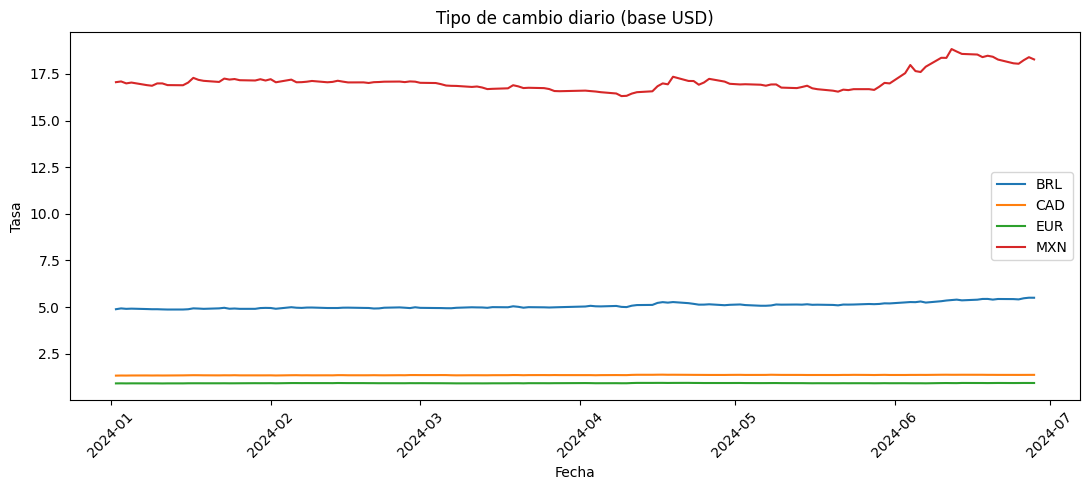

In [2]:
fig, ax = plt.subplots(figsize=(11, 5))
for currency, group in enriched_pdf.groupby("currency"):
    ax.plot(group["date"], group["rate"], label=currency)
ax.set_title("Tipo de cambio diario (base USD)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Tasa")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. Anomalías detectadas (variación diaria > 2 desv. estándar)

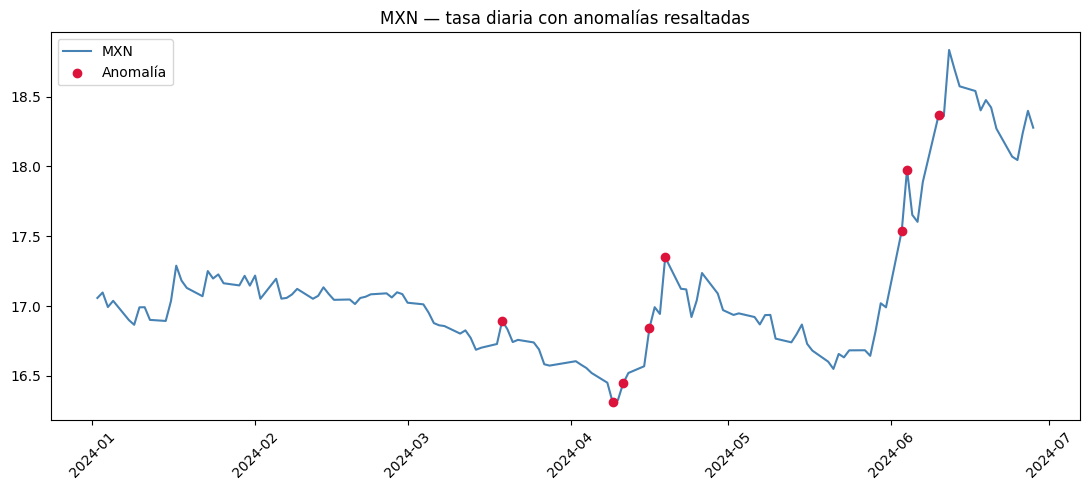

Anomalías detectadas en MXN: 8 de 126 observaciones


In [3]:
mxn = enriched_pdf[enriched_pdf["currency"] == "MXN"]
mxn_anomalies = anomalies_pdf[anomalies_pdf["currency"] == "MXN"]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(mxn["date"], mxn["rate"], label="MXN", color="steelblue")
ax.scatter(mxn_anomalies["date"], mxn_anomalies["rate"], color="crimson", zorder=5, label="Anomalía")
ax.set_title("MXN — tasa diaria con anomalías resaltadas")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Anomalías detectadas en MXN: {len(mxn_anomalies)} de {len(mxn)} observaciones")

## 3. Volatilidad mensual por moneda

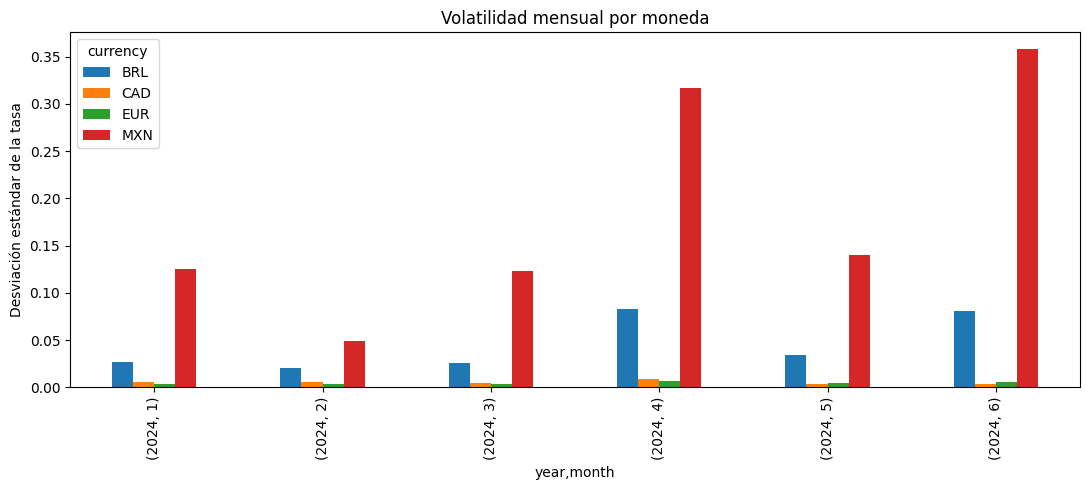

In [4]:
pivot = monthly_pdf.pivot(index=["year", "month"], columns="currency", values="monthly_volatility")
pivot.plot(kind="bar", figsize=(11, 5), title="Volatilidad mensual por moneda")
plt.ylabel("Desviación estándar de la tasa")
plt.tight_layout()
plt.show()

## 4. Solicitudes de crédito vs. volatilidad del tipo de cambio (segunda fuente)

Cruce de `db.riesgo_diario` (join entre solicitudes de crédito y tipo de cambio MXN).

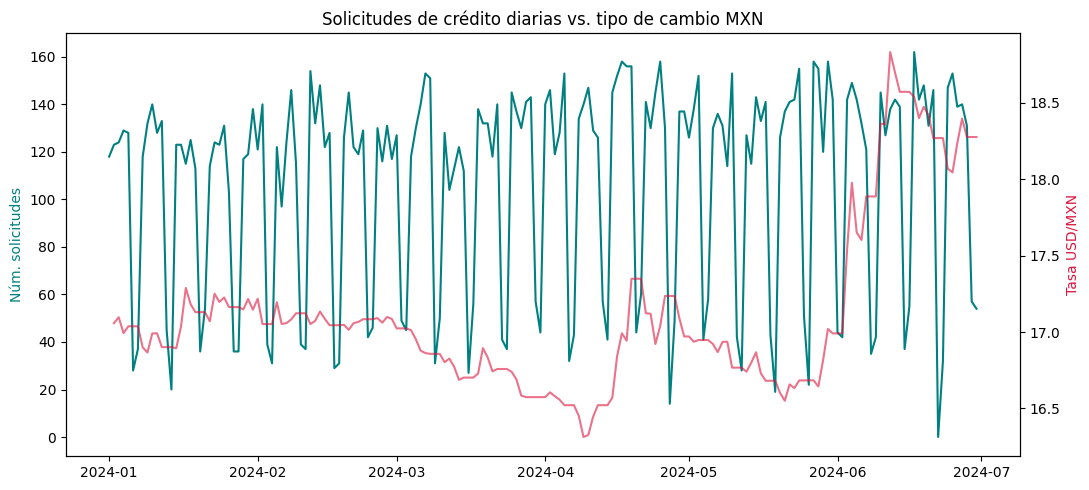

Correlación (solicitudes vs. tasa MXN): 0.015


In [5]:
if load.table_exists(spark, "daily_risk"):
    risk_pdf = load.read_table(spark, "daily_risk").toPandas().sort_values("date")

    fig, ax1 = plt.subplots(figsize=(11, 5))
    ax1.plot(risk_pdf["date"], risk_pdf["num_solicitudes"], color="teal", label="Solicitudes de crédito")
    ax1.set_ylabel("Núm. solicitudes", color="teal")

    ax2 = ax1.twinx()
    ax2.plot(risk_pdf["date"], risk_pdf["mxn_rate_filled"], color="crimson", alpha=0.6, label="Tasa MXN")
    ax2.set_ylabel("Tasa USD/MXN", color="crimson")

    plt.title("Solicitudes de crédito diarias vs. tipo de cambio MXN")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    correlation = risk_pdf["num_solicitudes"].corr(risk_pdf["mxn_rate_filled"])
    print(f"Correlación (solicitudes vs. tasa MXN): {correlation:.3f}")
else:
    print("db.riesgo_diario no existe todavía — corre el pipeline principal primero.")

In [6]:
spark.stop()